# 🌅 Computación Fotónica y GBS aplicados al Go
## ¿Qué hace una computadora de luz que no pueden hacer las otras?

Este notebook recorre tres paradigmas cuánticos usando **el mismo tablero de Go** como hilo conductor:

| Paradigma | Hardware | Problema natural | Para el Go |
|---|---|---|---|
| D-Wave | Qubits de flujo | Minimizar QUBO | Encontrar configuración de menor energía |
| IBM/Google | Qubits transmon | Circuitos de puertas | Evolución temporal del Hamiltoniano |
| **Xanadu** | **Modos ópticos** | **Muestreo de grafos** | **¿Qué grupos son estructuralmente fuertes?** |

Este notebook cubre el paradigma fotónico de principio a fin:
1. Qué es un fotón como recurso computacional
2. El hafniano y por qué cuenta emparejamientos
3. Cómo se conecta a grafos y GBS
4. El tablero de Go como grafo (reutilizando el motor)
5. Qué encuentra GBS en una posición de Go

In [3]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, FancyArrowPatch
import matplotlib.gridspec as gridspec
import networkx as nx
from itertools import combinations
from math import factorial
import warnings
warnings.filterwarnings('ignore')

# Motor de Go (importar como paquete para respetar imports relativos internos)
from src.board_utils import board_from_matrix, board_to_numpy, board_to_adjacency, board_to_cfg
from src.go_game_engine import SGFParser

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('✅ Todo listo')

✅ Todo listo


---
## Sección 1 — El fotón en el espacio de fases

### ¿Por qué el fotón es diferente a un qubit?

Un **qubit** (IBM, D-Wave) vive en un espacio de 2 dimensiones: {|0⟩, |1⟩}.

Un **modo fotónico** (Xanadu) vive en un espacio *continuo*: está descrito por
dos variables conjugadas — la cuadratura de **posición** x̂ y la cuadratura de **momento** p̂.
Son análogos a la posición y velocidad de un oscilador armónico.

El **principio de incertidumbre** dice: Δx · Δp ≥ 1/2

Los tres estados fundamentales:
- **Vacío**: Δx = Δp = 1/√2 — círculo en el espacio de fases
- **Coherente**: como el vacío pero desplazado — misma forma, diferente centro
- **Squeezed (comprimido)**: Δx < 1/√2 a costa de Δp > 1/√2 — elipse en el espacio de fases

GBS usa estados *squeezed* porque concentran la incertidumbre en una sola cuadratura,
creando correlaciones cuánticas que son el recurso computacional.

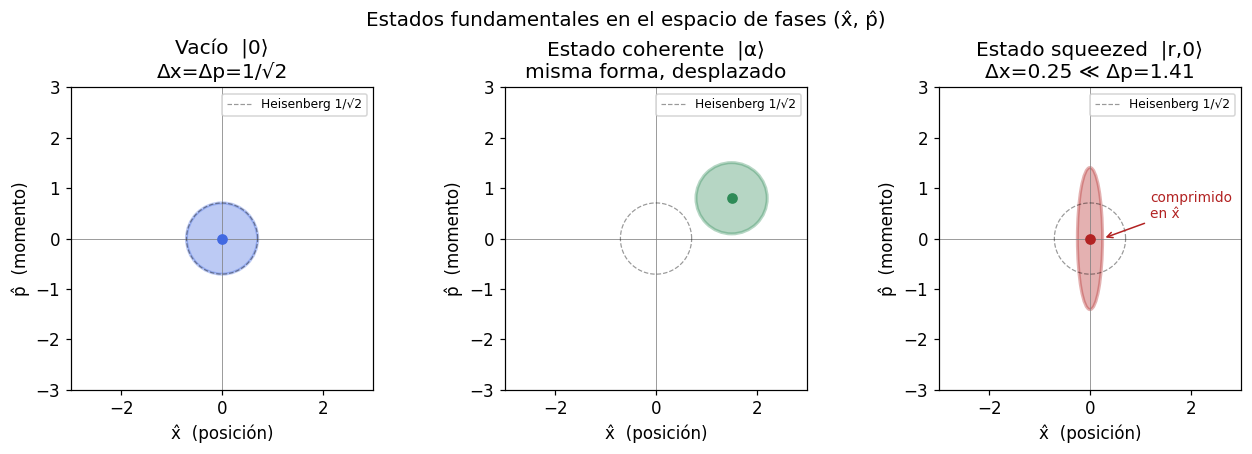

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Estados fundamentales en el espacio de fases (x̂, p̂)', fontsize=13)

def draw_state(ax, x0=0, p0=0, sx=1, sp=1, color='steelblue',
               title='', n_photons_label=''):
    """Dibuja la elipse de incertidumbre en el espacio de fases."""
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel('x̂  (posición)'); ax.set_ylabel('p̂  (momento)')
    ax.set_aspect('equal')
    # elipse de incertidumbre (1σ)
    ellipse = Ellipse((x0, p0), width=2*sx, height=2*sp,
                      facecolor=color, alpha=0.35, edgecolor=color, lw=2)
    ax.add_patch(ellipse)
    ax.plot(x0, p0, 'o', color=color, ms=6)
    # límite de Heisenberg
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(0.707*np.cos(theta), 0.707*np.sin(theta),
            'k--', lw=0.8, alpha=0.4, label='Heisenberg 1/√2')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')

draw_state(axes[0], sx=0.707, sp=0.707, color='royalblue',
           title='Vacío  |0⟩\nΔx=Δp=1/√2')
draw_state(axes[1], x0=1.5, p0=0.8, sx=0.707, sp=0.707, color='seagreen',
           title='Estado coherente  |α⟩\nmisma forma, desplazado')
draw_state(axes[2], sx=0.25, sp=1.41, color='firebrick',
           title='Estado squeezed  |r,0⟩\nΔx=0.25 ≪ Δp=1.41')

# anotación squeeze
axes[2].annotate('comprimido\nen x̂', xy=(0.25, 0), xytext=(1.2, 0.4),
                 arrowprops=dict(arrowstyle='->', color='firebrick'),
                 color='firebrick', fontsize=9)

plt.tight_layout()
plt.savefig('../results/01_estados_fase.png', bbox_inches='tight')
plt.show()

---
## Sección 2 — El divisor de haz y la interferencia fotónica

### El divisor de haz (beam splitter)

Un divisor de haz 50/50 mezcla dos modos:
```
modo a ──┤BS├── modo a' = (a + b) / √2
modo b ──┤BS├── modo b' = (a - b) / √2
```
Esta operación es **unitaria** — no pierde información, solo la redistribuye.

### Efecto Hong-Ou-Mandel (HOM): los fotones se agrupan

Si entran **dos fotones idénticos**, uno por cada puerto del divisor:
- Clásicamente esperarías: a veces salen juntos, a veces separados
- Cuánticamente: **siempre salen juntos** por el mismo puerto

Esto se debe a que los fotones son **bosones** — partículas que prefieren
ocupar el mismo estado. Es la raíz del poder computacional de GBS:
los fotones se agrupan en subgrafos densos de la red.

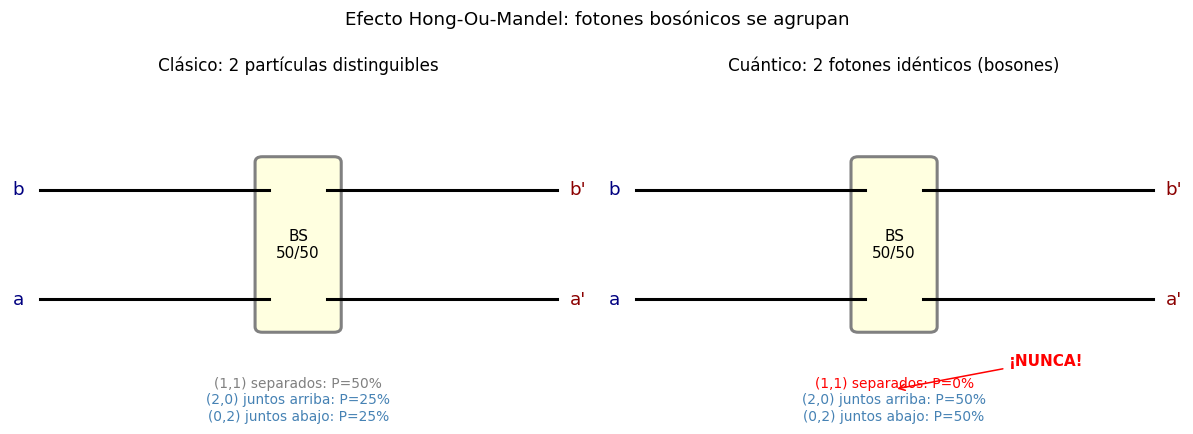

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Efecto Hong-Ou-Mandel: fotones bosónicos se agrupan', fontsize=12)

def draw_bs_circuit(ax, title, outcomes, probs, colors):
    ax.set_xlim(0, 4); ax.set_ylim(-0.5, 2.5)
    ax.axis('off')
    ax.set_title(title, fontsize=11)
    # líneas de modo
    ax.plot([0.2, 1.8], [0.5, 0.5], 'k-', lw=2)
    ax.plot([0.2, 1.8], [1.5, 1.5], 'k-', lw=2)
    ax.plot([2.2, 3.8], [0.5, 0.5], 'k-', lw=2)
    ax.plot([2.2, 3.8], [1.5, 1.5], 'k-', lw=2)
    # caja BS
    rect = mpatches.FancyBboxPatch((1.75, 0.25), 0.5, 1.5,
                                   boxstyle='round,pad=0.05',
                                   fc='lightyellow', ec='gray', lw=2)
    ax.add_patch(rect)
    ax.text(2.0, 1.0, 'BS\n50/50', ha='center', va='center', fontsize=10)
    ax.text(0.05, 0.5, 'a', ha='center', va='center', fontsize=12, color='navy')
    ax.text(0.05, 1.5, 'b', ha='center', va='center', fontsize=12, color='navy')
    ax.text(3.95, 0.5, "a'", ha='center', va='center', fontsize=12, color='darkred')
    ax.text(3.95, 1.5, "b'", ha='center', va='center', fontsize=12, color='darkred')
    # resultados
    for k, (out, prob, col) in enumerate(zip(outcomes, probs, colors)):
        ax.text(2.0, -0.3 - k*0.15, f'{out}: P={prob:.0%}',
                ha='center', fontsize=9, color=col)

draw_bs_circuit(axes[0],
    'Clásico: 2 partículas distinguibles',
    ['(1,1) separados', '(2,0) juntos arriba', '(0,2) juntos abajo'],
    [0.5, 0.25, 0.25],
    ['gray', 'steelblue', 'steelblue'])

draw_bs_circuit(axes[1],
    'Cuántico: 2 fotones idénticos (bosones)',
    ['(1,1) separados', '(2,0) juntos arriba', '(0,2) juntos abajo'],
    [0.0, 0.5, 0.5],
    ['red', 'steelblue', 'steelblue'])

axes[1].annotate('¡NUNCA!', xy=(2.0, -0.32), xytext=(2.8, -0.1),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/02_HOM.png', bbox_inches='tight')
plt.show()

---
## Sección 3 — El hafniano

### ¿Qué es un emparejamiento perfecto?

Dado un grafo G, un **emparejamiento perfecto** es una forma de conectar
todos los nodos en pares sin repetir ninguno.

```
Grafo de 4 nodos {0,1,2,3} — emparejamientos perfectos:
  μ₁ = {(0,1), (2,3)}
  μ₂ = {(0,2), (1,3)}
  μ₃ = {(0,3), (1,2)}
```

### El hafniano

El **hafniano** de una matriz simétrica 2n×2n es:
```
haf(A) = Σ_{μ ∈ M(2n)}  Π_{(i,j) ∈ μ}  A[i,j]
```
Suma sobre todos los emparejamientos perfectos del producto de los pesos de las aristas.

**Conexión con GBS:**  
La probabilidad de detectar fotones en el conjunto de nodos S es:
```
P(S) ∝ |haf(A_S)|²
```
donde A_S es la submatriz de A indexada por S.

Grafo denso → muchos emparejamientos → hafniano grande → alta probabilidad de detección.

In [6]:
def hafnian(A: np.ndarray) -> float:
    """Hafniano de una matriz simétrica 2n×2n.
    
    Recursión: fija el emparejamiento del índice 0 con cada j > 0,
    luego llama recursivamente sobre la submatriz sin esos dos índices.
    Complejidad: O((2n-1)!!) — práctico para n ≤ 7.
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    assert A.shape == (n, n) and n % 2 == 0, 'Necesita matriz cuadrada de tamaño par'
    if n == 0:
        return 1.0
    if n == 2:
        return A[0, 1]
    result = 0.0
    for j in range(1, n):
        # Emparejar índice 0 con índice j
        remaining = [k for k in range(n) if k != 0 and k != j]
        sub = A[np.ix_(remaining, remaining)]
        result += A[0, j] * hafnian(sub)
    return result


# ── Verificación manual ──────────────────────────────────────────────────
# Grafo completo K4 (todos los nodos conectados con peso 1)
K4 = np.array([[0,1,1,1],
               [1,0,1,1],
               [1,1,0,1],
               [1,1,1,0]], dtype=float)

# Emparejamientos perfectos de K4: (01)(23), (02)(13), (03)(12)
# Cada uno con peso 1×1 = 1  →  haf = 3
h = hafnian(K4)
print(f'haf(K4) = {h:.1f}  (esperado: 3.0  — tres emparejamientos perfectos)')

# Camino lineal  0-1-2-3 (solo aristas adyacentes)
PATH4 = np.array([[0,1,0,0],
                  [1,0,1,0],
                  [0,1,0,1],
                  [0,0,1,0]], dtype=float)
print(f'haf(PATH4) = {hafnian(PATH4):.1f}  (esperado: 1.0  — solo (01)(23))')

haf(K4) = 3.0  (esperado: 3.0  — tres emparejamientos perfectos)
haf(PATH4) = 1.0  (esperado: 1.0  — solo (01)(23))


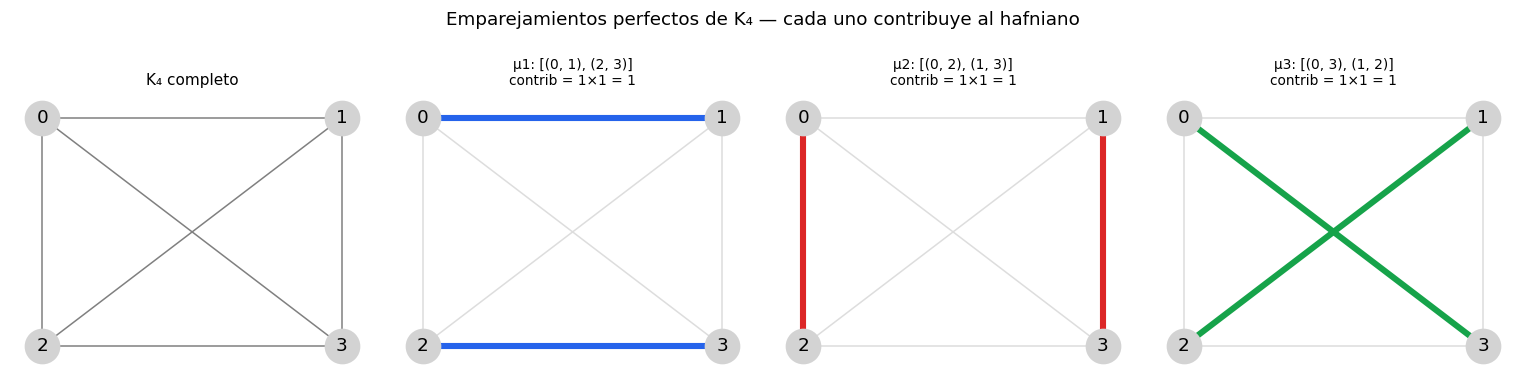

haf(K4) = 1 + 1 + 1 = 3  ✓


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.suptitle('Emparejamientos perfectos de K₄ — cada uno contribuye al hafniano', fontsize=12)

pos = {0: (0, 1), 1: (1, 1), 2: (0, 0), 3: (1, 0)}
G_K4 = nx.complete_graph(4)
matchings = [[(0,1),(2,3)], [(0,2),(1,3)], [(0,3),(1,2)]]
colors_m = ['#2563EB', '#DC2626', '#16a34a']

# Panel 0: grafo completo
nx.draw(G_K4, pos, ax=axes[0], with_labels=True, node_color='lightgray',
        edge_color='gray', node_size=500)
axes[0].set_title('K₄ completo', fontsize=10)

# Paneles 1-3: cada emparejamiento
for k, (matching, col) in enumerate(zip(matchings, colors_m)):
    ax = axes[k+1]
    nx.draw(G_K4, pos, ax=ax, with_labels=True, node_color='lightgray',
            edge_color='#ddd', node_size=500)
    nx.draw_networkx_edges(G_K4, pos, edgelist=matching, ax=ax,
                           edge_color=col, width=4)
    ax.set_title(f'μ{k+1}: {matching}\ncontrib = 1×1 = 1', fontsize=9)

plt.tight_layout()
plt.savefig('../results/03_matchings.png', bbox_inches='tight')
plt.show()
print('haf(K4) = 1 + 1 + 1 = 3  ✓')

---
## 🏋️ Ejercicio 1 — Triángulo vs camino lineal

El triángulo (K₃) tiene 3 nodos.  Para GBS necesitamos matrices de tamaño **par**,
así que trabajamos con un **K₄** (cuadrado completo) vs un camino lineal de 4 nodos.

**Pregunta**: ¿cuál de las dos estructuras produce un hafniano mayor?  
**Respuesta esperada**: K₄ tiene más emparejamientos perfectos → hafniano más alto
→ mayor probabilidad de detección en GBS.

In [8]:
def gbs_probs_subgraphs(A: np.ndarray, max_size: int = 4) -> list:
    """Calcula P(S) ∝ haf(A_S)² para todos los subconjuntos pares de tamaño ≤ max_size."""
    n = len(A)
    results = []
    for size in range(2, min(max_size, n) + 1, 2):  # solo tamaños pares
        for subset in combinations(range(n), size):
            idx = list(subset)
            A_sub = A[np.ix_(idx, idx)]
            haf_val = hafnian(A_sub)
            results.append({'subset': idx, 'size': size,
                            'hafnian': haf_val, 'prob_unnorm': haf_val**2})
    total = sum(r['prob_unnorm'] for r in results)
    for r in results:
        r['prob'] = r['prob_unnorm'] / total if total > 0 else 0.0
    return sorted(results, key=lambda x: x['prob'], reverse=True)


# Dos grafos de 4 nodos
A_dense = K4.copy()                          # K4: todos conectados
A_sparse = PATH4.copy()                      # camino 0-1-2-3

probs_dense  = gbs_probs_subgraphs(A_dense,  max_size=4)
probs_sparse = gbs_probs_subgraphs(A_sparse, max_size=4)

print('=== Subconjunto completo {0,1,2,3} ===')
d = next(r for r in probs_dense  if r['subset'] == [0,1,2,3])
s = next(r for r in probs_sparse if r['subset'] == [0,1,2,3])
print(f'  K4    → haf={d["hafnian"]:.1f}, P={d["prob"]:.1%}')
print(f'  PATH4 → haf={s["hafnian"]:.1f}, P={s["prob"]:.1%}')

=== Subconjunto completo {0,1,2,3} ===
  K4    → haf=3.0, P=60.0%
  PATH4 → haf=1.0, P=25.0%


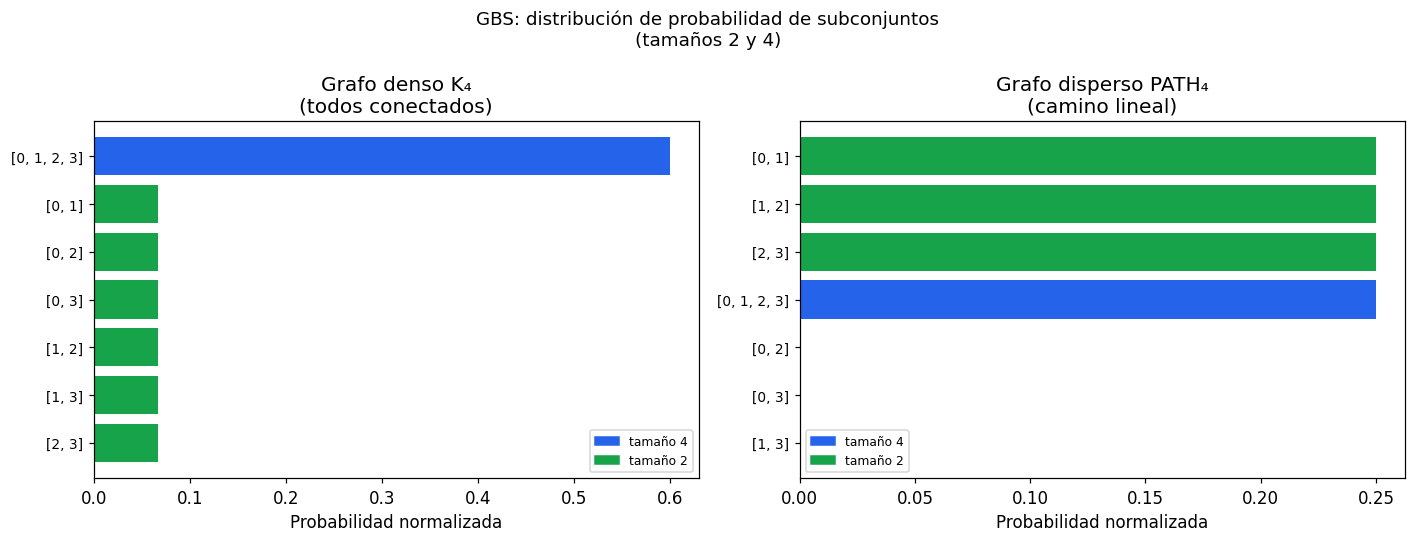

🔵 Los subconjuntos de tamaño 4 dominan en K4 — grafo denso favorecido por GBS


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('GBS: distribución de probabilidad de subconjuntos\n(tamaños 2 y 4)', fontsize=12)

def plot_gbs_probs(ax, probs, title, top_n=10):
    top = probs[:top_n]
    labels = [str(r['subset']) for r in top]
    vals   = [r['prob'] for r in top]
    colors = ['#2563EB' if len(r['subset'])==4 else '#16a34a' for r in top]
    ax.barh(range(len(top)), vals, color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Probabilidad normalizada')
    ax.set_title(title)
    ax.invert_yaxis()
    # leyenda
    p1 = mpatches.Patch(color='#2563EB', label='tamaño 4')
    p2 = mpatches.Patch(color='#16a34a', label='tamaño 2')
    ax.legend(handles=[p1, p2], fontsize=8)

plot_gbs_probs(axes[0], probs_dense,  'Grafo denso K₄\n(todos conectados)')
plot_gbs_probs(axes[1], probs_sparse, 'Grafo disperso PATH₄\n(camino lineal)')

plt.tight_layout()
plt.savefig('../results/04_gbs_basico.png', bbox_inches='tight')
plt.show()
print('🔵 Los subconjuntos de tamaño 4 dominan en K4 — grafo denso favorecido por GBS')

---
## Sección 4 — El tablero de Go como grafo

### Tres formas de construir el grafo

```
Esquema 'neutral'       : A[i,j] = 1 si (i,j) son intersecciones adyacentes
                          Captura solo la topología del tablero

Esquema 'ferromagnético': A[i,j] = +1 si mismo color
                                 = -0.5 si colores distintos
                                 =  0.1 si hay vacíos
                          Captura las alianzas entre grupos de piedras

Common Fate Graph (CFG) : Nodos = grupos + celdas vacías
                          Aristas = libertades compartidas
                          El grafo original de Graepel (2001)
```

Para GBS usaremos el esquema **ferromagnético** sobre un tablero 5×5:
es suficientemente pequeño para visualizar y suficientemente rico para mostrar grupos.

In [10]:
# Tablero 5×5 de ejemplo con dos grupos claros
matrix_5x5 = [
    list('..B..'),
    list('.BBB.'),
    list('B.B.W'),
    list('.WWW.'),
    list('..W..'),
]
gb   = board_from_matrix(matrix_5x5)
board = board_to_numpy(gb)

print('Tablero:')
for row in board:
    print(' '.join(row))

Tablero:
. . B . .
. B B B .
B . B . W
. W W W .
. . W . .


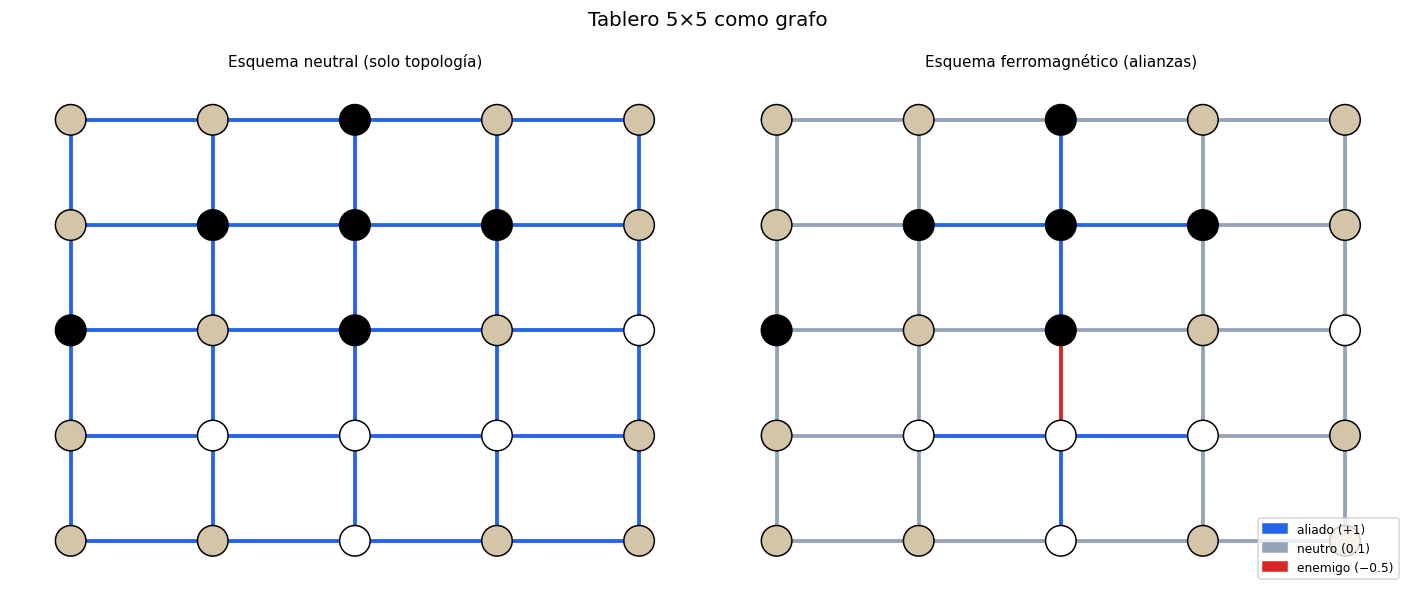

In [11]:
# Construir las dos matrices
A_neutral = board_to_adjacency(board, scheme='neutral')
A_ferro   = board_to_adjacency(board, scheme='ferromagnetic')

n, m = board.shape
N = n * m  # 25 nodos para 5×5

# Función de posición: (i,j) -> (col, fila_invertida) para que coincida con Go
node_pos = {i*m + j: (j, n-1-i) for i in range(n) for j in range(m)}

# Colores de nodos
stone_colors = []
for i in range(n):
    for j in range(m):
        c = board[i, j]
        stone_colors.append('black' if c=='B' else ('white' if c=='W' else '#d4c5a9'))

stone_border = ['black'] * N

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Tablero 5×5 como grafo', fontsize=13)

for ax, A, title in zip(axes, [A_neutral, A_ferro],
                         ['neutral (solo topología)', 'ferromagnético (alianzas)']):
    G = nx.from_numpy_array(np.abs(A))  # networkx no admite pesos negativos en draw
    # filtrar aristas con peso > 0
    edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 0.001]
    edge_colors = []
    for u, v in edges:
        w = A[u, v]
        if w > 0.5:
            edge_colors.append('#2563EB')   # aliado fuerte
        elif w > 0.05:
            edge_colors.append('#94a3b8')   # neutro
        else:
            edge_colors.append('#DC2626')   # enemigo
    nx.draw(G, node_pos, ax=ax, nodelist=range(N),
            edgelist=edges,
            node_color=stone_colors,
            edge_color=edge_colors,
            node_size=400, width=2.5,
            edgecolors='black', linewidths=1)
    ax.set_title(f'Esquema {title}', fontsize=10)
    ax.set_facecolor('#f0ebe0')

# leyenda
p1 = mpatches.Patch(color='#2563EB', label='aliado (+1)')
p2 = mpatches.Patch(color='#94a3b8', label='neutro (0.1)')
p3 = mpatches.Patch(color='#DC2626', label='enemigo (−0.5)')
axes[1].legend(handles=[p1, p2, p3], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('../results/05_board_graph.png', bbox_inches='tight')
plt.show()

### El Common Fate Graph (CFG)

El CFG reduce el grafo: en lugar de una intersección por nodo, tiene **un nodo por grupo**.
Los grupos se conectan a sus libertades (celdas vacías adyacentes).

Es más compacto y captura directamente la estructura estratégica:
dos grupos que comparten libertades son vecinos en el CFG — sus destinos están interconectados.

CFG: 18 nodos
Nodos: ['B_0', 'B_1', 'W_0', 'W_1', 'E_(0,0)', 'E_(0,1)', 'E_(0,3)', 'E_(0,4)', 'E_(1,0)', 'E_(1,4)', 'E_(2,1)', 'E_(2,3)', 'E_(3,0)', 'E_(3,4)', 'E_(4,0)', 'E_(4,1)', 'E_(4,3)', 'E_(4,4)']


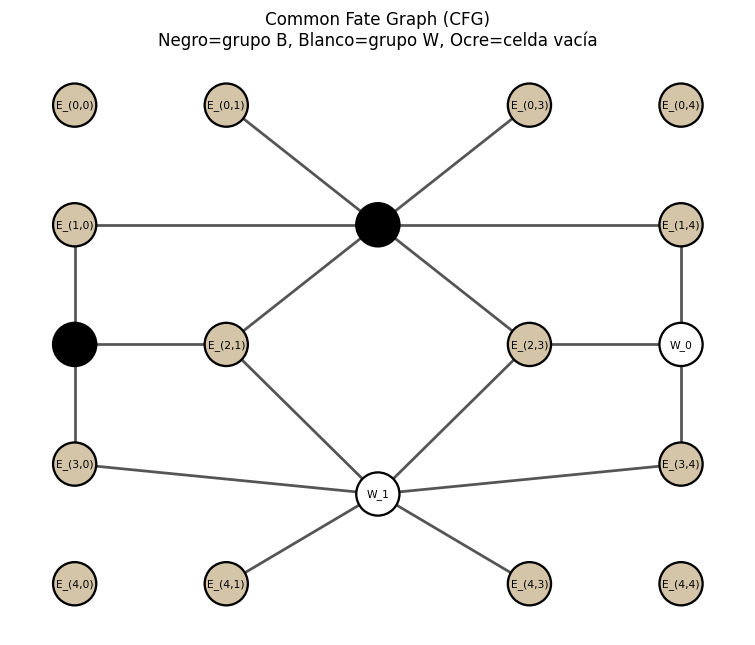

In [12]:
A_cfg, labels, cfg_pos = board_to_cfg(board)

print(f'CFG: {len(labels)} nodos')
print('Nodos:', labels)

G_cfg = nx.from_numpy_array(A_cfg)

cfg_node_colors = []
for lbl in labels:
    if lbl.startswith('B'): cfg_node_colors.append('black')
    elif lbl.startswith('W'): cfg_node_colors.append('white')
    else: cfg_node_colors.append('#d4c5a9')

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor('#f0ebe0')
ax.set_title('Common Fate Graph (CFG)\nNegro=grupo B, Blanco=grupo W, Ocre=celda vacía',
             fontsize=11)

nx.draw(G_cfg, cfg_pos, ax=ax, labels=dict(enumerate(labels)),
        node_color=cfg_node_colors, edgecolors='black', linewidths=1.5,
        node_size=800, font_size=7, edge_color='#555', width=1.8)

plt.tight_layout()
plt.savefig('../results/06_cfg.png', bbox_inches='tight')
plt.show()

---
## Sección 5 — GBS en el tablero de Go

### Preparación de la matriz

Para que GBS sea físicamente válido, los eigenvalores de la matriz A deben
tener valor absoluto **< 1**. Normalizamos:
```python
A_norm = A / (max|eigenvalores| + ε)
```

Luego calculamos el hafniano de cada subconjunto de nodos para encontrar
cuáles tienen mayor probabilidad de ser detectados en GBS.

**Para el tablero 5×5 completo (25 nodos, subconjuntos de tamaño 4)**
hay C(25,4) = 12,650 subconjuntos — factible en CPU.

In [13]:
# Normalizar la matriz ferromagnética
eigvals = np.linalg.eigvalsh(A_ferro)
A_norm  = A_ferro / (np.max(np.abs(eigvals)) + 0.05)

print(f'Eigenvalores originales: min={eigvals.min():.3f}, max={eigvals.max():.3f}')
print(f'Después de normalizar:   max|λ| = {np.max(np.abs(np.linalg.eigvalsh(A_norm))):.3f}')

# GBS: calcular haf(A_S)² para todos los subconjuntos de tamaño 4
# (solo tamaño 4 por eficiencia; tamaños mayores son muy lentos sin thewalrus)
print('\nCalculando hafnianos para subconjuntos de tamaño 4...')
results = []
for subset in combinations(range(N), 4):
    idx    = list(subset)
    A_sub  = A_norm[np.ix_(idx, idx)]
    haf_sq = hafnian(A_sub) ** 2
    results.append((idx, haf_sq))

results.sort(key=lambda x: x[1], reverse=True)
total = sum(r[1] for r in results)
results_norm = [(idx, prob/total) for idx, prob in results]

print(f'Total subconjuntos evaluados: {len(results)}')
print('\nTop-10 subconjuntos por probabilidad GBS:')
for idx, prob in results_norm[:10]:
    # convertir índices a coordenadas
    coords = [(k//m, k%m) for k in idx]
    stones = [board[r,c] for r,c in coords]
    print(f'  nodos={idx}  coords={coords}  piedras={stones}  P={prob:.4%}')

Eigenvalores originales: min=-2.070, max=2.070
Después de normalizar:   max|λ| = 0.976

Calculando hafnianos para subconjuntos de tamaño 4...
Total subconjuntos evaluados: 12650

Top-10 subconjuntos por probabilidad GBS:
  nodos=[2, 7, 16, 17]  coords=[(0, 2), (1, 2), (3, 1), (3, 2)]  piedras=[np.str_('B'), np.str_('B'), np.str_('W'), np.str_('W')]  P=6.6533%
  nodos=[2, 7, 17, 18]  coords=[(0, 2), (1, 2), (3, 2), (3, 3)]  piedras=[np.str_('B'), np.str_('B'), np.str_('W'), np.str_('W')]  P=6.6533%
  nodos=[2, 7, 17, 22]  coords=[(0, 2), (1, 2), (3, 2), (4, 2)]  piedras=[np.str_('B'), np.str_('B'), np.str_('W'), np.str_('W')]  P=6.6533%
  nodos=[6, 7, 16, 17]  coords=[(1, 1), (1, 2), (3, 1), (3, 2)]  piedras=[np.str_('B'), np.str_('B'), np.str_('W'), np.str_('W')]  P=6.6533%
  nodos=[6, 7, 17, 18]  coords=[(1, 1), (1, 2), (3, 2), (3, 3)]  piedras=[np.str_('B'), np.str_('B'), np.str_('W'), np.str_('W')]  P=6.6533%
  nodos=[6, 7, 17, 22]  coords=[(1, 1), (1, 2), (3, 2), (4, 2)]  piedras=[

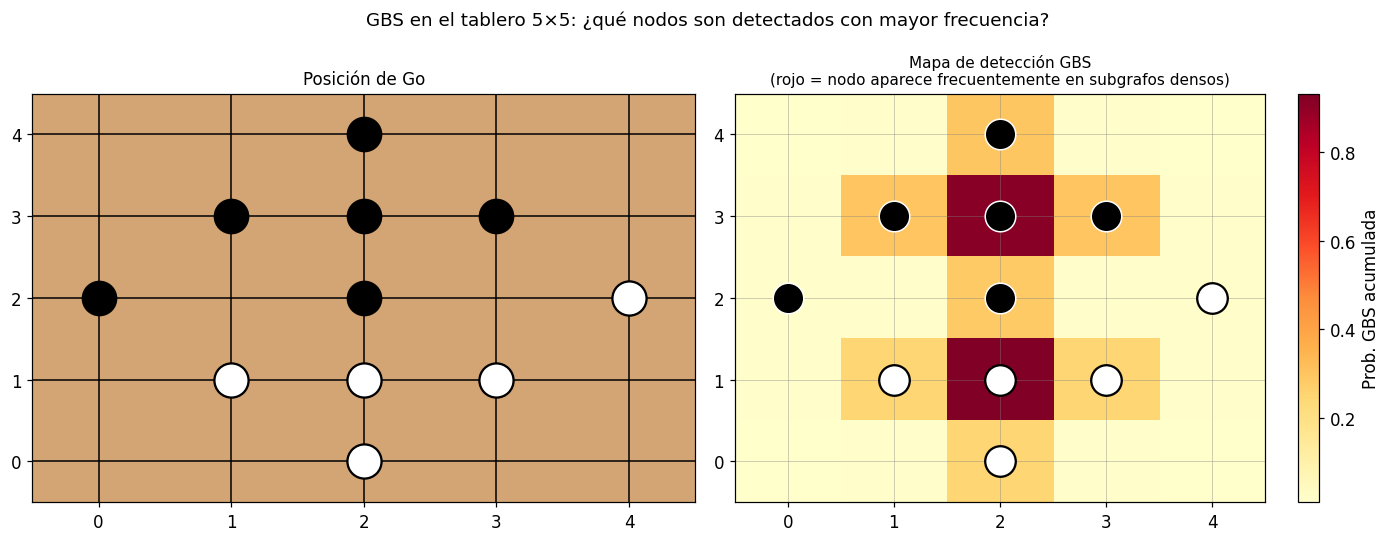

In [14]:
# Mapa de calor: probabilidad acumulada de detección por nodo
node_prob = np.zeros(N)
for idx, prob in results_norm:
    for k in idx:
        node_prob[k] += prob

heatmap = node_prob.reshape(n, m)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('GBS en el tablero 5×5: ¿qué nodos son detectados con mayor frecuencia?',
             fontsize=12)

# Panel izquierdo: tablero original
ax = axes[0]
ax.set_facecolor('#d4a574')
ax.set_xlim(-0.5, m-0.5); ax.set_ylim(-0.5, n-0.5)
ax.set_xticks(range(m)); ax.set_yticks(range(n))
ax.set_title('Posición de Go', fontsize=11)
for i in range(n):
    ax.axhline(i, color='black', lw=1)
for j in range(m):
    ax.axvline(j, color='black', lw=1)
for i in range(n):
    for j in range(m):
        c = board[i, j]
        if c == 'B':
            ax.scatter(j, n-1-i, s=500, color='black', zorder=5)
        elif c == 'W':
            ax.scatter(j, n-1-i, s=500, facecolors='white',
                       edgecolors='black', linewidths=1.5, zorder=5)

# Panel derecho: mapa de calor GBS
ax2 = axes[1]
im = ax2.imshow(heatmap[::-1], cmap='YlOrRd', aspect='auto',
                extent=[-0.5, m-0.5, -0.5, n-0.5])
ax2.set_facecolor('#d4a574')
for i in range(n):
    ax2.axhline(i, color='gray', lw=0.5, alpha=0.5)
for j in range(m):
    ax2.axvline(j, color='gray', lw=0.5, alpha=0.5)
# superponer piedras
for i in range(n):
    for j in range(m):
        c = board[i, j]
        if c == 'B':
            ax2.scatter(j, n-1-i, s=400, color='black', zorder=5,
                        edgecolors='white', linewidths=1)
        elif c == 'W':
            ax2.scatter(j, n-1-i, s=400, facecolors='white',
                        edgecolors='black', linewidths=1.5, zorder=5)
plt.colorbar(im, ax=ax2, label='Prob. GBS acumulada')
ax2.set_title('Mapa de detección GBS\n(rojo = nodo aparece frecuentemente en subgrafos densos)',
              fontsize=10)

plt.tight_layout()
plt.savefig('../results/07_gbs_heatmap.png', bbox_inches='tight')
plt.show()

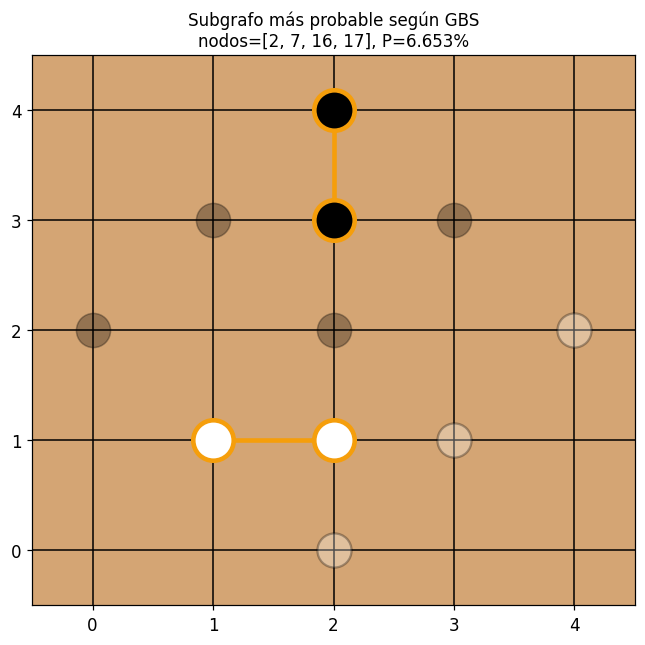

In [15]:
# Visualizar el subgrafo más probable sobre el tablero
top_idx, top_prob = results_norm[0]
top_coords = [(k//m, k%m) for k in top_idx]

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('#d4a574')
ax.set_xlim(-0.5, m-0.5); ax.set_ylim(-0.5, n-0.5)
ax.set_title(f'Subgrafo más probable según GBS\n'
             f'nodos={top_idx}, P={top_prob:.3%}', fontsize=11)
for i in range(n):
    ax.axhline(i, color='black', lw=1)
for j in range(m):
    ax.axvline(j, color='black', lw=1)

# piedras base
for i in range(n):
    for j in range(m):
        c = board[i, j]
        if c == 'B':
            ax.scatter(j, n-1-i, s=500, color='black', zorder=4, alpha=0.3)
        elif c == 'W':
            ax.scatter(j, n-1-i, s=500, facecolors='white',
                       edgecolors='black', lw=1.5, zorder=4, alpha=0.3)

# resaltar nodos del subgrafo
for ri, rj in top_coords:
    c = board[ri, rj]
    fc = 'black' if c == 'B' else ('white' if c == 'W' else '#f59e0b')
    ax.scatter(rj, n-1-ri, s=700, facecolors=fc,
               edgecolors='#f59e0b', linewidths=3, zorder=6)

# aristas del subgrafo (si son adyacentes en el tablero)
for (r1,c1), (r2,c2) in combinations(top_coords, 2):
    if abs(r1-r2) + abs(c1-c2) == 1:  # adyacentes en el tablero
        ax.plot([c1, c2], [n-1-r1, n-1-r2], '-', color='#f59e0b', lw=3, zorder=5)

plt.tight_layout()
plt.savefig('../results/08_gbs_top_subgraph.png', bbox_inches='tight')
plt.show()

---
## Sección 6 — ¿Qué encontró GBS? Interpretación

### Lo que GBS detecta

GBS favorece los subgrafos que tienen **el mayor hafniano** — es decir,
los que tienen más emparejamientos perfectos con pesos altos.

En el tablero ferromagnético:
- Las **aristas fuertes (+1)** son entre piedras del mismo color adyacentes
- Los subgrafos densos de un mismo color → muchos emparejamientos → hafniano alto

**Traducción a Go:** GBS señala los *grupos internamente más conectados*.
Un grupo de 4 piedras negras todas adyacentes entre sí tiene hafniano máximo.
Ese no es exactamente el concepto de 'mejor jugada' pero sí captura:

| GBS detecta | Concepto en Go |
|---|---|
| Subgrafo denso mismo color | Grupo sólido / fuerte |
| Subgrafo mixto de alta conectividad | Zona de contacto / lucha |
| Nodos aislados (baja probabilidad) | Piedras débiles / con pocas libertades |

### Lo que GBS NO detecta
- El valor estratégico de un movimiento
- El territorio final
- La secuencia óptima de jugadas

GBS responde a una pregunta **topológica**: '¿dónde está la mayor densidad de conexiones?'
No a una pregunta **estratégica**: '¿qué debo jugar?'

---
## Sección 7 — Los tres paradigmas cuánticos: comparación

```
                   D-Wave              IBM / Google           Xanadu
────────────────────────────────────────────────────────────────────────
Sustrato físico   Qubits de flujo      Qubits transmon        Modos ópticos
                  superconductores     superconductores       (fotones)

Temperatura       ~15 mK               ~15 mK                 Temperatura
                                                               ambiente

Variable          Discreta: {0,1}      Discreta: {0,1}        Continua: (x̂,p̂)
computacional

Operaciones       Evolución             Puertas unitarias      Beam splitters
nativas           adiabática           (CNOT, H, T, ...)      + squeezing

Problema         Minimizar             Circuito general;      Muestreo de
natural           H(s) = Σ J s_i s_j   QAOA, VQE, Shor        subgrafos densos

Para Go           QUBO del tablero:    Evolución e^{-iHt}     CFG → GBS →
                  configuración de     del Hamiltoniano;      subgrafos fuertes
                  mínima energía       QAOA para QUBO

Pregunta que      '¿Cuál es el         '¿Cómo evoluciona      '¿Dónde están
responde          territorio           el tablero bajo        los grupos más
                  óptimo?'             este Hamiltoniano?'    conectados?'

Acceso actual     Filtrado /           IBM Quantum            Simulador en
                  restringido          (acceso libre)         PennyLane

Ventaja cuántica  En sistemas           En circuitos           En hafnianos
genuina           grandes (QUBO        profundos con          de grafos
                  NP-hard)             muchos qubits          irregulares > 50
                                                              nodos
────────────────────────────────────────────────────────────────────────
```

### El mensaje central

> **'Computadora cuántica' no es una categoría única.**  
> Igual que 'computadora clásica' no distingue entre CPU, GPU y FPGA,
> D-Wave, IBM y Xanadu explotan principios físicos diferentes
> y son adecuadas para clases de problemas distintas.
> El Go, con su riqueza de estructura de grafos, estado ternario {B,W,vacío}
> y necesidad de optimización, es un campo de prueba natural para las tres.

---
## 🏋️ Ejercicio 2 — Explora tus propias posiciones

Modifica la celda siguiente para cargar una partida SGF de la carpeta
`data/sgf partidas/` y aplicar GBS a un movimiento específico.

In [16]:
import glob
from src.sgf_utils import extract_moves_and_info, replay_game

# Carga una partida SGF
sgf_files = sorted(glob.glob('../data/sgf partidas/*.sgf'))
print(f'Partidas disponibles: {len(sgf_files)}')
print('Primera:', os.path.basename(sgf_files[0]))

# --- Descomenta y ajusta el movimiento que quieras analizar ---
# sgf_path = sgf_files[0]
# moves, winner, info = extract_moves_and_info(sgf_path)
# move_number = 30  # analiza el tablero en la jugada 30
# gb_sgf = replay_game(moves[:move_number], size=info.get('board_size', 19))
# board_sgf = board_to_numpy(gb_sgf)
#
# # Para tableros grandes, trabaja sobre una ventana 9×9 del centro
# cx, cy = board_sgf.shape[0]//2, board_sgf.shape[1]//2
# window = board_sgf[cx-4:cx+5, cy-4:cy+5]
# A_w = board_to_adjacency(window, scheme='ferromagnetic')
# eigvals_w = np.linalg.eigvalsh(A_w)
# A_w_norm = A_w / (np.max(np.abs(eigvals_w)) + 0.05)
#
# nw = window.shape[0] * window.shape[1]
# results_w = []
# for subset in combinations(range(nw), 4):
#     idx = list(subset)
#     A_sub = A_w_norm[np.ix_(idx, idx)]
#     haf_sq = hafnian(A_sub)**2
#     results_w.append((idx, haf_sq))
# results_w.sort(key=lambda x: x[1], reverse=True)
# print('Top-5 subgrafos en la partida:', results_w[:5])
print('\n(Descomenta el bloque de arriba para analizar una partida real)')

Partidas disponibles: 4000
Primera: 31mn-gokifu-20200319-Gu_Lingyi-Tao_Xinran.sgf

(Descomenta el bloque de arriba para analizar una partida real)


---
## Resumen

1. **Los fotones son bosones** — se agrupan. Eso es el recurso computacional.
2. **El hafniano** cuenta emparejamientos perfectos ponderados de un grafo.
3. **GBS** produce muestras cuya probabilidad es proporcional a |haf(A_S)|².
4. **En el tablero de Go**, los subgrafos de mayor hafniano corresponden
   a grupos de piedras internamente bien conectados.
5. **GBS responde a '¿dónde están los grupos fuertes?'**, no a '¿qué jugada hacer?'
6. **Los tres paradigmas** (D-Wave, IBM, Xanadu) responden preguntas distintas
   sobre el mismo tablero — son herramientas complementarias, no equivalentes.

### Siguientes pasos
- Construir el QUBO del tablero completo (D-Wave / SimAnnealing)
- Usar QAOA en PennyLane para aproximar el mínimo del QUBO (IBM)
- Correlacionar los subgrafos GBS con la evaluación de KataGo para validar
  si la densidad de conexiones predice la fuerza estratégica